In [51]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel("Online Retail.xlsx")

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df = df.dropna(subset=['CustomerID'])

In [9]:
df = df.drop_duplicates()

In [10]:
df = df[df['Quantity'] > 0]

In [11]:
df = df[df['UnitPrice'] > 0]

In [56]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [57]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Month', 'Revenue'],
      dtype='object')


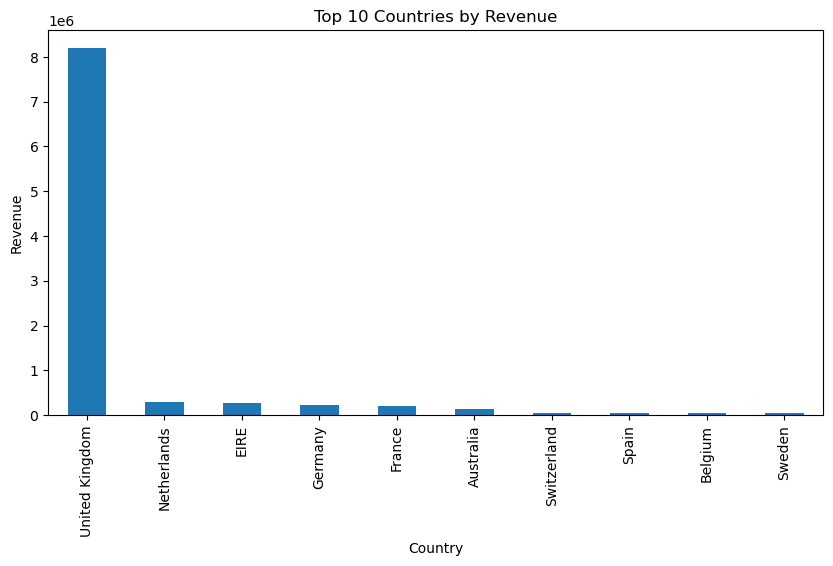

In [45]:

country_sales = (
    df.groupby('Country')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
country_sales.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

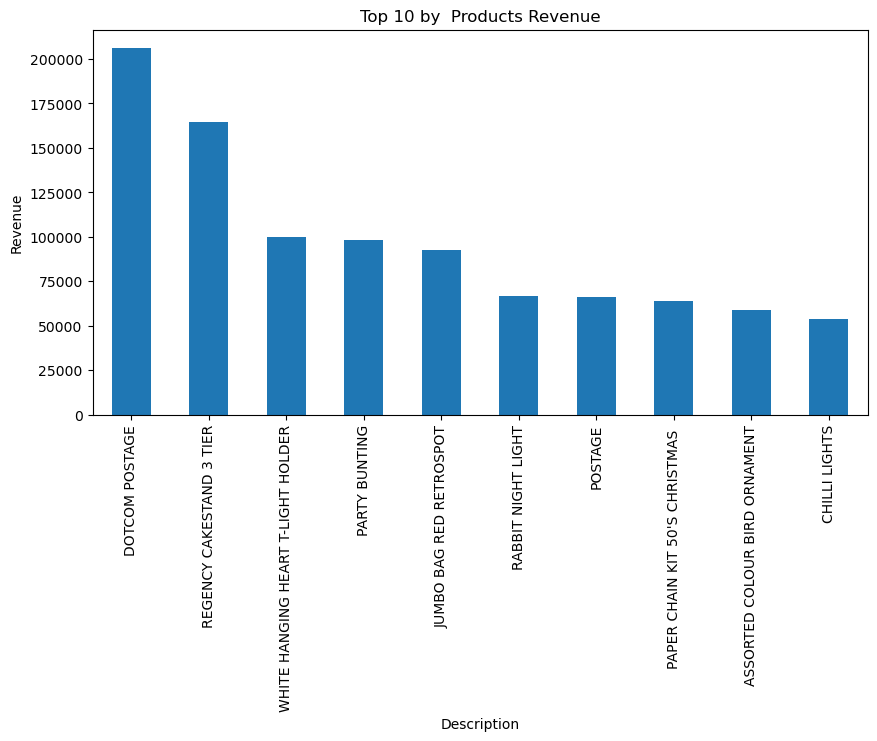

In [61]:
product_sales = (
    df.groupby('Description')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

product_sales.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 by  Products Revenue")
plt.xlabel("Description")
plt.ylabel("Revenue")
plt.show()

In [15]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [54]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

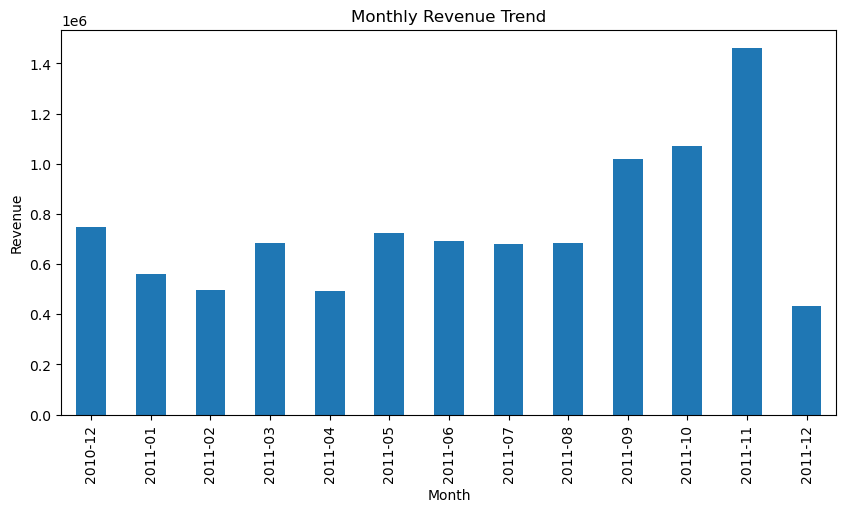

In [58]:
monthly_sales = df.groupby('Month')['Revenue'].sum()

monthly_sales.plot(kind='bar', figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

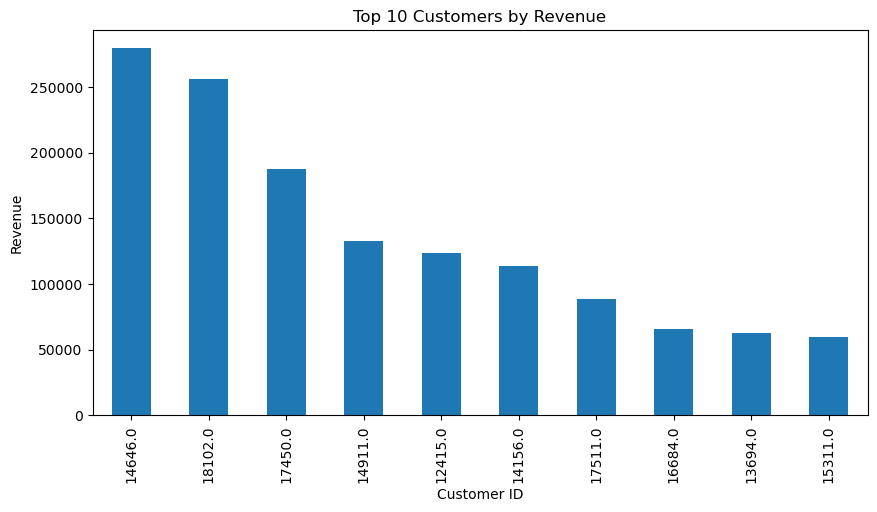

In [62]:
top_customers = (
    df.groupby('CustomerID')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

In [19]:
total_transactions = len(df)

unique_customers = df['CustomerID'].nunique()

top_customers_count = 100

total_revenue = df['Revenue'].sum()

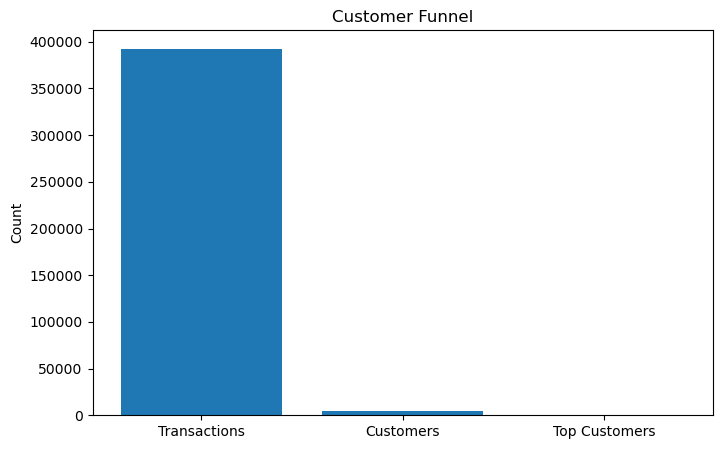

In [60]:


funnel_data = {
    'Transactions': total_transactions,
    'Customers': unique_customers,
    'Top Customers': top_customers_count
}

plt.figure(figsize=(8,5))
plt.bar(funnel_data.keys(), funnel_data.values())
plt.title("Customer Funnel")
plt.ylabel("Count")
plt.show()

In [20]:
print("Total Transactions:", total_transactions)
print("Unique Customers:", unique_customers)
print("Top Customers Considered:", top_customers_count)
print("Total Revenue:", round(total_revenue, 2))

Total Transactions: 392692
Unique Customers: 4338
Top Customers Considered: 100
Total Revenue: 8887208.89


In [52]:
country_sales.head()
product_sales.head()

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
Name: Revenue, dtype: float64

# Business Insights Report

## Executive Summary

This analysis was performed on the Online Retail dataset. Data cleaning included handling missing values, removing duplicates, and filtering invalid transactions.

## Key Findings

- Revenue is concentrated in a few countries.
- A small group of customers generates a significant portion of sales.
- Certain products contribute disproportionately to total revenue.
- Sales show seasonal variation across months.

## Recommendations

- Focus marketing budget on high-revenue countries.
- Create loyalty programs for top customers.
- Promote best-selling products more aggressively.
- Schedule campaigns before peak sales periods.

In [59]:
df.to_csv("cleaned_online_retail.csv", index=False)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!
